In [ ]:
import pandas as pd

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
import ast # secondary_labelsを評価するため
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import os

# train.csvを読み込む
df = pd.read_csv("/kaggle/input/competitions/birdclef-2026/train.csv")

# class_nameが'Aves'のデータのみを抽出
bird_df = df[df["class_name"] == "Aves"].copy()

# 抽出したデータを新しいCSVファイルとして保存
bird_df.to_csv("/kaggle/working/train_birds.csv", index=False)

print("鳥類のデータフレームを作成し、'train_birds.csv'として保存しました。")
print(f"元のデータ数: {len(df)}")
print(f"抽出後のデータ数: {len(bird_df)}")

In [21]:
# 定数の設定
INPUT_DIR = "/kaggle/input/competitions/birdclef-2026"
TRAIN_AUDIO_DIR = os.path.join(INPUT_DIR, "train_audio")
OUT_FIG_PATH = "/kaggle/working/trim_zeroed_comparison.png"
SAMPLING_RATE = 32000
TOP_DB = 20 # 無音と判断するデシベル閾値

In [22]:
def plot_waveform(y, sr, title, ax):
    """音声波形をプロットする関数"""
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")


In [23]:
def trim_with_zeros(y, top_db=TOP_DB):
    """
    音声の前後にある無音区間を検出し、その部分を0にする。
    librosa.effects.trim は無音区間を削除するが、ここでは元の長さを維持する。
    """
    # 無音でない区間のインデックスを取得
    non_silent_indices = librosa.effects.split(y, top_db=top_db)
    
    # 有効な音声区間が一つでもあれば、その最初と最後のインデックスを取得
    if len(non_silent_indices) > 0:
        start_trim = non_silent_indices[0][0]
        end_trim = non_silent_indices[-1][1]
        
        # 元の音声と同じ長さのゼロ配列を作成
        y_trimmed_zeroed = np.zeros_like(y)
        
        # 無音でない部分だけをコピー
        y_trimmed_zeroed[start_trim:end_trim] = y[start_trim:end_trim]
        
        return y_trimmed_zeroed
    else:
        # 全体が無音と判断された場合は、そのままゼロ配列を返す
        return np.zeros_like(y)

処理対象ファイル: /kaggle/input/competitions/birdclef-2026/train_audio/osprey/iNat502184.ogg
鳥の種類: osprey
比較画像を '/kaggle/working/trim_zeroed_comparison.png' として保存しました。


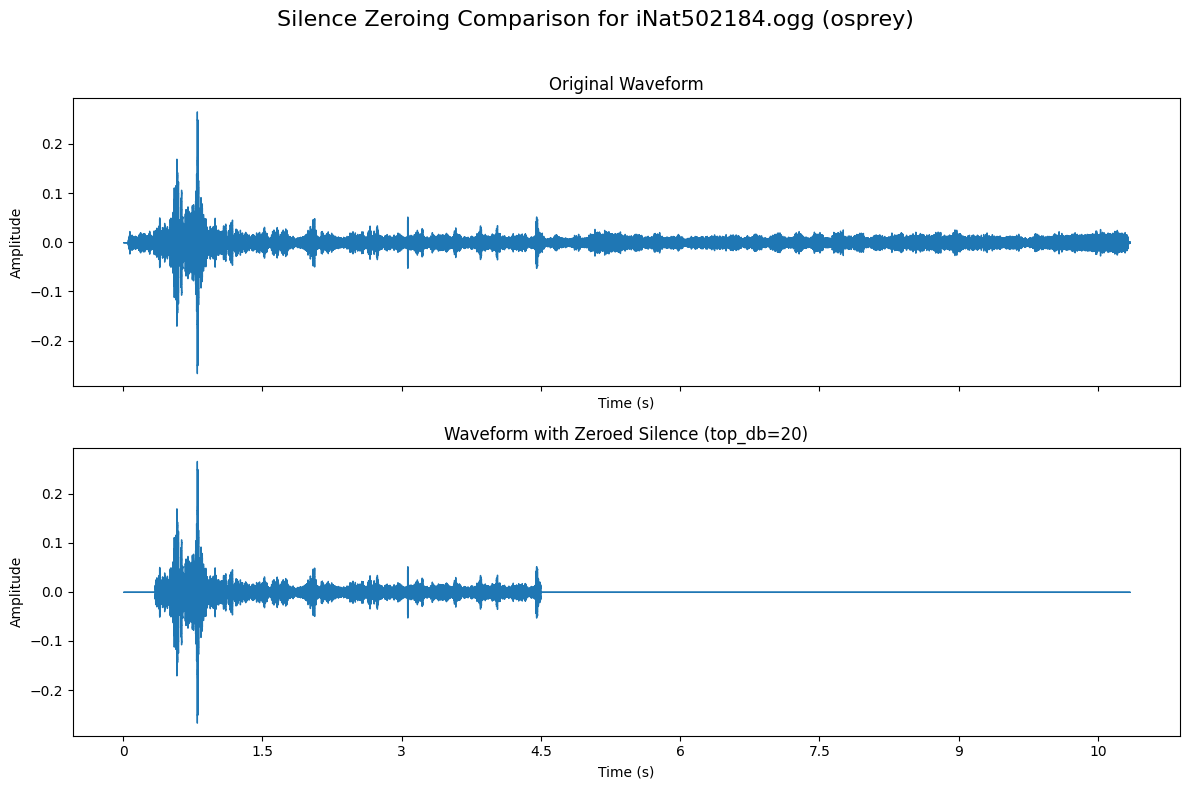

In [24]:
def main():
    # 鳥類データCSVを読み込み
    bird_df = pd.read_csv("train_birds.csv")

    # ランダムに1つ音声ファイルを選択
    sample = bird_df.sample(1).iloc[0]
    filename = sample["filename"]
    primary_label = sample["primary_label"]
    filepath = os.path.join(TRAIN_AUDIO_DIR, filename)

    print(f"処理対象ファイル: {filepath}")
    print(f"鳥の種類: {primary_label}")

    # 音声ファイルを読み込み
    try:
        y, sr = librosa.load(filepath, sr=SAMPLING_RATE)
    except Exception as e:
        print(f"ファイル読み込みエラー: {e}")
        return

    # 無音区間をゼロ化する処理を適用
    y_processed = trim_with_zeros(y)

    # 処理前後の波形をプロット
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

    plot_waveform(y, sr, "Original Waveform", axes[0])
    plot_waveform(y_processed, sr, f"Waveform with Zeroed Silence (top_db={TOP_DB})", axes[1])

    fig.suptitle(f"Silence Zeroing Comparison for {os.path.basename(filename)} ({primary_label})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # プロットを画像として保存
    plt.savefig(OUT_FIG_PATH)
    print(f"比較画像を '{OUT_FIG_PATH}' として保存しました。")

if __name__ == "__main__":
    main()


あんなりきれいにならないのは音声が、混ざっているから

In [25]:
# --- 定数の設定 ---
INPUT_DIR = "/kaggle/input/competitions/birdclef-2026"
TRAIN_AUDIO_DIR = os.path.join(INPUT_DIR, "train_audio")
OUTPUT_NPZ_PATH = "/kaggle/working/multilabel_dataset.npz"

In [26]:
# 音声処理に関する設定
SAMPLING_RATE = 32000
N_MELS = 128  # メルスペクトログラムの次元数
FMAX = 16000  # メルスペクトログラムの最大周波数
CHUNK_DURATION = 5  # 5秒のチャンク
CHUNK_SAMPLES = SAMPLING_RATE * CHUNK_DURATION  # 160,000 サンプル

In [27]:
def get_feature_vector(y, sr=SAMPLING_RATE, n_mels=N_MELS, fmax=FMAX):
    """
    音声波形チャンクからメルスペクトログラムを計算し、時間平均の特徴量ベクトルを返す。
    """
    try:
        melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=fmax)
        melspec_db = librosa.power_to_db(melspec, ref=np.max)
        feature_vector = np.mean(melspec_db, axis=1)
        return feature_vector
    except Exception as e:
        return None

In [ ]:
def main():
    print("1. データの読み込みとマージ")
    # 鳥類のデータのみを対象とする
    train_df = pd.read_csv("/kaggle/working/train_birds.csv")
    taxonomy_df = pd.read_csv("/kaggle/input/competitions/birdclef-2026/taxonomy.csv")

    # 鳥類のコードから学名へのマッピングを作成
    code_to_scientific_name_map = dict(zip(taxonomy_df['primary_label'], taxonomy_df['scientific_name']))

    # 鳥類の学名をソートしてインデックス化
    bird_species = sorted(taxonomy_df[taxonomy_df['class_name'] == 'Aves']['scientific_name'].unique())
    species_to_idx = {species: i for i, species in enumerate(bird_species)}
    num_classes = len(species_to_idx)

    # 処理するデータ数を制限せずに全てのデータを対象とする
    train_sample_df = train_df.reset_index(drop=True)

    print(f"\n2. {len(train_sample_df)}個の音声ファイルから特徴量とラベルを抽出します。")

    all_features = []
    all_labels = []

    # 3. メインループ: チャンク分割と特徴量抽出
    for idx, row in tqdm(train_sample_df.iterrows(), total=len(train_sample_df), desc="音声ファイル処理中"):
        
        # 3a. マルチホットラベルの作成 (ファイル全体に適用)
        # 該当ファイルの全ラベルをリストアップ
        file_species_scientific_names = set()
        
        # primary_labelの学名を追加
        file_species_scientific_names.add(row['scientific_name'])
        
        # secondary_labelsの学名を解析して追加
        # secondary_labelsは文字列として保存されているので、ast.literal_evalでリストに変換
        secondary_labels_list = ast.literal_eval(row['secondary_labels'])
        
        for sec_code in secondary_labels_list:
            if sec_code in code_to_scientific_name_map:
                file_species_scientific_names.add(code_to_scientific_name_map[sec_code])

        # マルチホットベクトルを作成
        label_vector = np.zeros(num_classes, dtype=np.float32)
        for species_name in file_species_scientific_names:
            if species_name in species_to_idx:
                idx = species_to_idx[species_name]
                label_vector[idx] = 1.0

        # 3b. 音声ファイルの読み込みとチャンク処理
        # filenameは primary_label/ファイル名.ogg の形式なので、primary_labelをパスから削除
        # train.csv の filename はすでに train_audio 以下からの相対パス
        filepath = os.path.join(TRAIN_AUDIO_DIR, row['filename'])
        
        try:
            y, sr = librosa.load(filepath, sr=SAMPLING_RATE)
        except Exception as e:
            print(f"  - 読み込みエラー: {filepath}, {e}")
            continue

        # 5秒チャンクに分割
        # librosa.load は通常32bit floatで音声を読み込む
        for i in range(0, len(y), CHUNK_SAMPLES):
            chunk = y[i : i + CHUNK_SAMPLES]
            
            # チャンクがCHUNK_SAMPLESに満たない場合はスキップ（最後の不完全なチャンク）
            if len(chunk) < CHUNK_SAMPLES:
                continue

            feature_vector = get_feature_vector(chunk, sr)
            
            if feature_vector is not None:
                all_features.append(feature_vector)
                all_labels.append(label_vector) # ファイル全体のマルチホットラベルを各チャンクに適用

    # 4. NumPy配列に変換して保存
    X = np.array(all_features)
    y = np.array(all_labels)

    print(f"\n4. 特徴量とラベルを '{OUTPUT_NPZ_PATH}' に保存します。")
    np.savez(OUTPUT_NPZ_PATH, X=X, y=y)

    print("\n--- 処理完了 ---")
    print(f"作成されたデータセットの形状: X={X.shape}, y={y.shape}")

if __name__ == "__main__":
    main()



1. データの読み込みとマージ

2. 34799個の音声ファイルから特徴量とラベルを抽出します。


音声ファイル処理中:  28%|██▊       | 9573/34799 [29:04<2:07:53,  3.29it/s] 

In [ ]:
# --- 定数の設定 ---
INPUT_DIR = "/kaggle/input/competitions/birdclef-2026"
DATASET_NPZ_PATH = "/kaggle/working/multilabel_dataset.npz"
RANDOM_STATE = 42

In [ ]:
def main():
    print("--- フェーズ2: マルチラベル分類モデルの構築と学習 ---")

    # 1. データセットの読み込み
    print("1. データセットを読み込んでいます...")
    data = np.load(os.path.join(INPUT_DIR, DATASET_NPZ_PATH))
    X = data['X']
    y = data['y']
    print(f"特徴量 X の形状: {X.shape}")
    print(f"ラベル y の形状: {y.shape}")

    # 2. データ分割
    print("\n2. データを学習用と検証用に分割しています...")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    print(f"学習データ数: {X_train.shape[0]}, 検証データ数: {X_val.shape[0]}")

    # 2.5. 学習データに対してオーバーサンプリングを適用
    print("\n2.5. 学習データに対して手動でオーバーサンプリングを適用しています...")

    # 各クラスのサンプル数を計算
    class_counts = np.sum(y_train, axis=0)
    
    # オーバーサンプリングのターゲット数を決定（例：クラスサンプル数の中央値、最低50）
    # 小さなデータセットではアグレッシブなオーバーサンプリングは避ける
    target_count = max(50, int(np.median(class_counts[class_counts > 0])))
    print(f"オーバーサンプリングのターゲットサンプル数（最低でもこの数を目指す）: {target_count}")

    # 元のデータをコピー
    X_train_resampled_list = [X_train]
    y_train_resampled_list = [y_train]
    
    num_classes = y_train.shape[1]

    for class_idx in range(num_classes):
        current_count = class_counts[class_idx]
        
        # サンプルが存在し、ターゲット数に満たない場合にオーバーサンプリング
        if 0 < current_count < target_count:
            num_to_add = target_count - int(current_count)
            
            # このクラスが陽性のサンプルのインデックスを取得
            positive_indices = np.where(y_train[:, class_idx] == 1)[0]
            
            # 複製するサンプルのインデックスをランダムに選択（重複を許す）
            resample_indices = np.random.choice(positive_indices, size=num_to_add, replace=True)
            
            # 複製したサンプルをリストに追加
            X_train_resampled_list.append(X_train[resample_indices])
            y_train_resampled_list.append(y_train[resample_indices])

    # リストを結合して最終的なリサンプリング済みデータセットを作成
    X_train = np.vstack(X_train_resampled_list)
    y_train = np.vstack(y_train_resampled_list)

    print(f"オーバーサンプリング後の学習データ数: {X_train.shape[0]}")

    # 3. モデル構築と学習
    print("\n3. LightGBM を使用してマルチラベル分類モデルを学習しています...")
    # LGBMClassifierのインスタンスを作成
    # CPUのみ使用するためn_jobs=-1を設定
    base_classifier = LGBMClassifier(objective='binary', random_state=RANDOM_STATE, n_jobs=-1)
    
    # MultiOutputClassifierでラップしてマルチラベルに対応
    model = MultiOutputClassifier(base_classifier, n_jobs=-1) # 各分類器を並列実行
    
    # モデルの学習
    model.fit(X_train, y_train)
    print("モデルの学習が完了しました。")

    # 4. モデル評価
    print("\n4. モデルの評価を行っています...")
    # 検証データで予測（確率）
    y_pred_proba = model.predict_proba(X_val)
    
    # predict_probaは各ラベルに対して (n_samples, 2) の配列を返すため、
    # 結合して (n_samples, n_labels) の形にする
    y_pred_proba_combined = np.array([pred[:, 1] for pred in y_pred_proba]).T

    # macro-averaged ROC-AUCを計算
    # roc_auc_scoreはy_trueとy_scoreをそれぞれ (n_samples, n_labels) の形式で期待する
    # y_val は既にこの形式
    # y_pred_proba_combined もこの形式
    roc_auc = roc_auc_score(y_val, y_pred_proba_combined, average='macro')
    print(f"検証データでの Macro-averaged ROC-AUC: {roc_auc:.4f}")

    print("\n--- 処理完了 ---")

if __name__ == "__main__":
    main()